In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/station_variable_statistics.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/gev_fit_scores_kmeans_gev_k3.csv")

# --- Merge labels into stats ---
# Ensure station is comparable dtype
stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

label_df = GEV_clusters[["station", "cluster", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on="station", how="inner")

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))

drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide", "lat", "lon", "count", "missing_frac")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster']

Stations for modeling: 279
cluster
1    136
0    122
2     21
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())


Train size: (209, 165)  Test size: (70, 165)
Train class counts:
 cluster
1    102
0     91
2     16
Name: count, dtype: int64
Test class counts:
 cluster
1    34
0    31
2     5
Name: count, dtype: int64


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    multi_class="multinomial",
    max_iter=5000,
    C=1.0,
    random_state=0
)

logit_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logit),
])

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scoring = {"acc": "accuracy", "f1w": "f1_weighted"}

cv_res = cross_validate(logit_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print("CV accuracy:", cv_res["test_acc"].mean(), "+/-", cv_res["test_acc"].std())
print("CV f1_weighted:", cv_res["test_f1w"].mean(), "+/-", cv_res["test_f1w"].std())
from sklearn.metrics import confusion_matrix, classification_report

logit_pipe.fit(X_train, y_train)
y_pred = logit_pipe.predict(X_test)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))


CV accuracy: 0.7803716608594657 +/- 0.08895176113532526
CV f1_weighted: 0.7767713582743344 +/- 0.0874865325542624
Confusion matrix:
 [[25  6  0]
 [ 8 26  0]
 [ 3  0  2]]

Report:
               precision    recall  f1-score   support

           0       0.69      0.81      0.75        31
           1       0.81      0.76      0.79        34
           2       1.00      0.40      0.57         5

    accuracy                           0.76        70
   macro avg       0.84      0.66      0.70        70
weighted avg       0.77      0.76      0.75        70



/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-pa

Attribution object 1: per-cluster feature means

In [5]:
cluster_means = model_df[["cluster"]].join(X).groupby("cluster").mean()
cluster_stds  = model_df[["cluster"]].join(X).groupby("cluster").std()
cluster_counts = model_df["cluster"].value_counts().sort_index()

print("\nPer-cluster means (first 10 features):\n", cluster_means.iloc[:, :10])



Per-cluster means (first 10 features):
          u10__mean  u10__std   u10__min   u10__max  u10__median  u10__q05  \
cluster                                                                     
0         1.463204  4.679777 -14.611848  21.631088     1.584177 -6.096385   
1         1.407061  4.844429 -16.235027  22.924685     1.569321 -6.530076   
2         1.458013  4.683684 -14.850274  22.026844     1.733997 -6.247502   

         u10__q95  u10__annmax_mean  u10__annmax_std  u10__annmax_min  
cluster                                                                
0        9.026230         16.574150         1.778157        13.342505  
1        9.203499         17.011209         1.747711        13.583266  
2        8.816459         16.068199         1.992556        12.681465  


# Anomalies

In [6]:
X_z = (X - X.mean()) / X.std(ddof=0)
cluster_anom = model_df[["cluster"]].join(X_z).groupby("cluster").mean()

print("\nPer-cluster standardized anomalies (first 10 features):\n", cluster_anom.iloc[:, :10])



Per-cluster standardized anomalies (first 10 features):
          u10__mean  u10__std  u10__min  u10__max  u10__median  u10__q05  \
cluster                                                                   
0         0.088038 -0.112639  0.317473 -0.241859    -0.008614  0.201310   
1        -0.090027  0.117593 -0.319369  0.231926    -0.040325 -0.190586   
2         0.071573 -0.107175  0.223928 -0.096912     0.311195  0.064757   

         u10__q95  u10__annmax_mean  u10__annmax_std  u10__annmax_min  
cluster                                                                
0       -0.054792         -0.084435        -0.005210        -0.038649  
1        0.082743          0.126483        -0.127557         0.098991  
2       -0.217543         -0.328598         0.856347        -0.416557  


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

Xs_df = pd.DataFrame(Xs, index=X.index, columns=X.columns)
Xs_df["cluster"] = model_df["cluster"].values
centroids_std = Xs_df.groupby("cluster").mean()

print("Centroids in standardized meteorological space:")
display(centroids_std.head())


Centroids in standardized meteorological space:


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__annmax_mean,u10__annmax_std,u10__annmax_min,...,swh__q05,swh__q95,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.088038,-0.112639,0.317473,-0.241859,-0.008614,0.201310,-0.054792,-0.084435,-0.005210,-0.038649,...,-0.279280,-0.184078,-0.154758,-0.178566,-0.110628,-0.173450,-0.211481,-0.231568,-0.233458,-0.218088
1,-0.090027,0.117593,-0.319369,0.231926,-0.040325,-0.190586,0.082743,0.126483,-0.127557,0.098991,...,0.297091,0.173078,0.132735,0.143711,0.089661,0.156348,0.209279,0.219712,0.230566,0.213357
2,0.071573,-0.107175,0.223928,-0.096912,0.311195,0.064757,-0.217543,-0.328598,0.856347,-0.416557,...,-0.150018,0.245466,0.399820,0.604346,0.364918,0.333323,0.123972,0.278763,0.143847,0.165106


In [9]:
centroids_phys = pd.DataFrame(
    scaler.inverse_transform(centroids_std),
    index=centroids_std.index,
    columns=X.columns
)

print("Centroids in physical units:")
display(centroids_phys.head())
centroid_spread = centroids_std.max(axis=0) - centroids_std.min(axis=0)
centroid_spread = centroid_spread.sort_values(ascending=False)

print("Variables defining centroid separation:")
print(centroid_spread.head(20))


Centroids in physical units:


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__annmax_mean,u10__annmax_std,u10__annmax_min,...,swh__q05,swh__q95,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.463204,4.679777,-14.611848,21.631088,1.584177,-6.096385,9.026230,16.574150,1.778157,13.342505,...,0.246738,2.057724,4.153114,0.530978,3.147438,5.734162,0.895297,0.061421,0.726518,1.032814
1,1.407061,4.844429,-16.235027,22.924685,1.569321,-6.530076,9.203499,17.011209,1.747711,13.583266,...,0.333686,2.337915,4.598934,0.620878,3.356475,6.503798,1.057370,0.074407,0.875422,1.224151
2,1.458013,4.683684,-14.850274,22.026844,1.733997,-6.247502,8.816459,16.068199,1.992556,12.681465,...,0.266238,2.394704,5.013106,0.749373,3.643754,6.916797,1.024511,0.076106,0.847594,1.202753


Variables defining centroid separation:
sst__q05             2.036037
sst__std             1.965970
sst__min             1.837344
sst__annmean_std     1.745010
t2m__q05             1.656688
t2m__annmean_std     1.656042
t2m__min             1.618875
d2m__annmean_std     1.613595
t2m__std             1.602838
d2m__std             1.600562
sst__median          1.592902
d2m__q05             1.574718
sst__annmax_std      1.573572
sst__annmean_min     1.568359
d2m__min             1.512420
sst__mean            1.482318
sst__annmean_mean    1.481514
t2m__annmean_min     1.420364
d2m__annmean_min     1.328913
sp__annmax_std       1.327764
dtype: float64


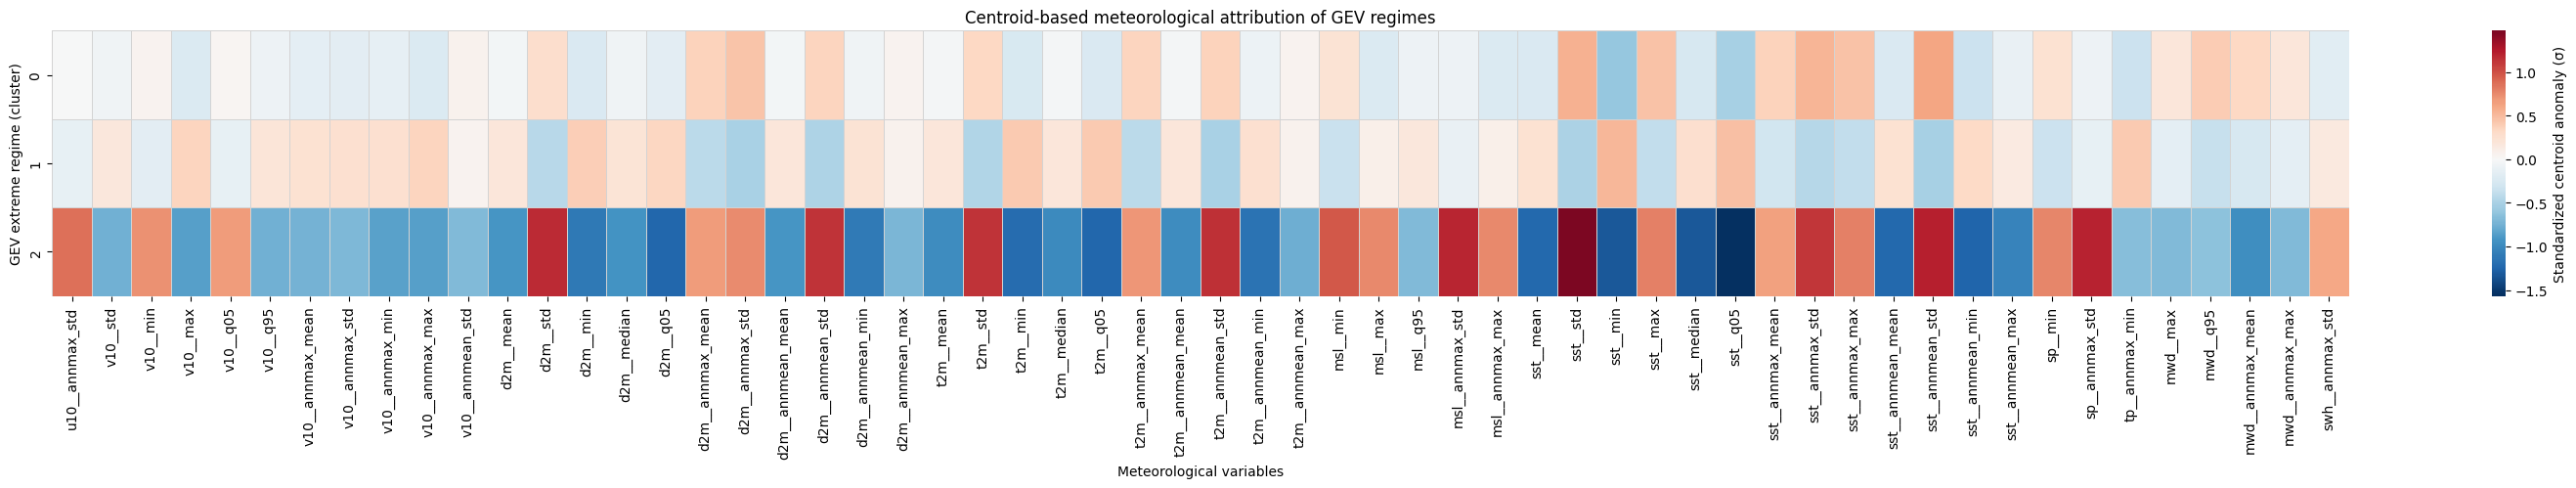

In [10]:
centroid_fingerprint = centroids_std.copy()

# Optional: drop weak signals
centroid_fingerprint = centroid_fingerprint.loc[
    :, centroid_fingerprint.abs().max() > 0.6
]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(0.45*centroid_fingerprint.shape[1] + 4,
                    0.7*centroid_fingerprint.shape[0] + 3))

sns.heatmap(
    centroid_fingerprint,
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Standardized centroid anomaly (σ)"}
)

plt.ylabel("GEV extreme regime (cluster)")
plt.xlabel("Meteorological variables")
plt.title("Centroid-based meteorological attribution of GEV regimes")
plt.tight_layout()
plt.show()



# Cluster Bath stats

In [11]:
ds_sealevel = GEV_clusters

In [12]:
# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

# extract station ids and their lat/lon
stations = ds_sealevel['station'].values
lats = ds_sealevel['lat'].values
lons = ds_sealevel['lon'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
#resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]
resolutions = [0.1, 0.25, 1]

# Initialize results dict
results = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}

# Build tiles for every (lat, lon) at every resolution
for lat, lon in unique_latlon:
    for size in resolutions:
        key = f"{size}x{size}"
        results[key].append(extract_square(GEBCO_ds, lat, lon, size))

In [13]:
import numpy as np
import xarray as xr

import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 128, W: int = 128) -> xr.Dataset:
    """
    Resize a tile to (H,W) using xarray interp.
    Robust to empty / degenerate tiles and to descending coords.
    """
    # Basic dimension checks
    if ("lat" not in ds_tile.dims) or ("lon" not in ds_tile.dims):
        raise ValueError(f"Tile missing lat/lon dims: dims={ds_tile.dims}")

    nlat = ds_tile.sizes.get("lat", 0)
    nlon = ds_tile.sizes.get("lon", 0)

    # Empty tile: return a blank (NaN) tile with target coords
    if nlat == 0 or nlon == 0:
        # Try to preserve variable names; create NaN arrays for vars on (lat, lon)
        lat = np.linspace(0.0, 0.0, H, dtype=np.float32)
        lon = np.linspace(0.0, 0.0, W, dtype=np.float32)
        out = xr.Dataset(coords={"lat": lat, "lon": lon})
        for v in ds_tile.data_vars:
            if set(ds_tile[v].dims) >= {"lat", "lon"}:
                out[v] = xr.DataArray(np.full((H, W), np.nan, dtype=np.float32), dims=("lat", "lon"))
        return out

    # Degenerate tile: interp needs at least 2 points along each axis for linear
    # (if you can accept nearest, you can switch methods conditionally)
    method = "linear"
    if nlat < 2 or nlon < 2:
        method = "nearest"

    # Ensure monotonic ascending coords for interp
    ds = ds_tile.sortby(["lat", "lon"])

    lat0 = float(ds["lat"].values[0])
    lat1 = float(ds["lat"].values[-1])
    lon0 = float(ds["lon"].values[0])
    lon1 = float(ds["lon"].values[-1])

    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    return ds.interp(lat=new_lat, lon=new_lon, method=method)

# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (128, 128), f"{k} -> {shp}, expected (128, 128)"

del GEBCO_ds

rows = []
for i, (lat, lon) in enumerate(unique_latlon):
    row = {"latitude": lat, "longitude": lon}
    for size in resolutions:
        key = f"{size}x{size}"
        xr_tile = results_128[key][i]
        elev = xr_tile["elevation"].where(xr_tile["elevation"] <= -0.5)
        row[f"tile_{size}"] = elev.values  # 2D array
        # save plotting extent = [lon_min, lon_max, lat_min, lat_max]
        row[f"extent_{size}"] = [
            float(xr_tile["lon"].min()), float(xr_tile["lon"].max()),
            float(xr_tile["lat"].min()), float(xr_tile["lat"].max())
        ]
    rows.append(row)

df = pd.DataFrame(rows)

In [14]:
import numpy as np

def _station_pixel_indices(st_lat, st_lon, extent, ny, nx):
    lon_min, lon_max, lat_min, lat_max = extent
    dlon = (lon_max - lon_min) / (nx - 1)
    dlat = (lat_max - lat_min) / (ny - 1)

    if lat_max >= lat_min:  # ascending latitude
        iy = int(round((st_lat - lat_min) / dlat))
    else:                   # descending latitude
        dlat = (lat_min - lat_max) / (ny - 1)
        iy = int(round((lat_min - st_lat) / dlat))

    ix = int(round((st_lon - lon_min) / dlon))
    iy = np.clip(iy, 0, ny - 1)
    ix = np.clip(ix, 0, nx - 1)
    return iy, ix, dlat, dlon

def _meters_per_degree(lat_deg):
    lat_rad = np.deg2rad(lat_deg)
    return 111_132.0, 111_320.0 * np.cos(lat_rad)

def tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells=3):
    """
    Stats in a (2r+1)^2 window near station:
      - slope (deg)   [mean of gradient magnitude in deg]
      - roughness std (m)
      - relief p2p (m)
      - mean bathymetry (m) over ocean-only cells (<= -0.5 m)
    """
    if tile is None or np.all(np.isnan(tile)):
        return np.nan, np.nan, np.nan, np.nan

    ny, nx = tile.shape
    iy, ix, dlat_deg, dlon_deg = _station_pixel_indices(st_lat, st_lon, extent, ny, nx)

    y0 = max(0, iy - radius_cells); y1 = min(ny, iy + radius_cells + 1)
    x0 = max(0, ix - radius_cells); x1 = min(nx, ix + radius_cells + 1)

    sub = tile[y0:y1, x0:x1]
    if sub.size == 0 or np.all(np.isnan(sub)):
        return np.nan, np.nan, np.nan, np.nan

    # Ocean-only mask for mean bathy
    sub_ocean = np.where(sub <= -0.5, sub, np.nan)
    mean_bathy = float(np.nanmean(sub_ocean))

    # Pixel spacings (meters) at station latitude
    m_per_deg_lat, m_per_deg_lon = _meters_per_degree(st_lat)
    dy_m = dlat_deg * m_per_deg_lat
    dx_m = dlon_deg * m_per_deg_lon

    # Gradients (fill small NaN gaps just for gradient)
    sub_filled = np.where(np.isnan(sub), np.nanmean(sub), sub) if np.isnan(sub).any() else sub
    gy, gx = np.gradient(sub_filled, dy_m, dx_m)
    slope_mag = np.sqrt(gx**2 + gy**2)           # rise/run
    slope_deg = np.degrees(np.arctan(slope_mag)) # to degrees
    slope_deg = np.where(np.isnan(sub), np.nan, slope_deg)

    slope_local = float(np.nanmean(slope_deg))
    roughness_std = float(np.nanstd(sub))
    relief_p2p = float(np.nanmax(sub) - np.nanmin(sub))

    return slope_local, roughness_std, relief_p2p, mean_bathy

# ---- Apply to all resolutions and add columns ----
radius_cells = 3  # e.g., 7x7 window; tweak as needed

for size in resolutions:  # [0.1, 0.25, 1.0, 3.0, 10.0]
    key = f"{size}"
    tile_col   = f"tile_{key}"
    extent_col = f"extent_{key}"

    df[f"slope_deg_{key}"]      = np.nan
    df[f"roughness_std_{key}"]  = np.nan
    df[f"relief_p2p_{key}"]     = np.nan
    df[f"mean_bathy_{key}"]     = np.nan

    for idx in range(len(df)):
        tile = df.at[idx, tile_col]
        extent = df.at[idx, extent_col]
        st_lat = df.at[idx, "latitude"]
        st_lon = df.at[idx, "longitude"]

        s, rstd, rpp, mb = tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells)
        df.at[idx, f"slope_deg_{key}"]     = s
        df.at[idx, f"roughness_std_{key}"] = rstd
        df.at[idx, f"relief_p2p_{key}"]    = rpp
        df.at[idx, f"mean_bathy_{key}"]    = mb

# Quick peek
print(df.filter(regex=r'^(latitude|longitude|slope_deg_|roughness_std_|relief_p2p_|mean_bathy_)').head())

    latitude  longitude  slope_deg_0.1  roughness_std_0.1  relief_p2p_0.1  \
0  48.383000  -4.495000       0.314652           0.618534        2.797581   
1  45.568480  -1.061555            NaN                NaN             NaN   
2  50.102000  -5.542000       0.469762           0.892700        4.550620   
3  50.103000  -5.542750       0.716422           1.212880        5.287394   
4  50.099998  -5.533330       0.471409           0.975480        4.209303   

   mean_bathy_0.1  slope_deg_0.25  roughness_std_0.25  relief_p2p_0.25  \
0       -1.354011        0.591017            2.602795         7.936331   
1             NaN             NaN                 NaN              NaN   
2       -4.932380        0.464575            2.025659         7.411496   
3       -4.070334        0.465226            2.143751         7.852673   
4       -8.839199        0.512022            2.552270        10.623257   

   mean_bathy_0.25  slope_deg_1  roughness_std_1  relief_p2p_1  mean_bathy_1  
0        -4.2

In [84]:
drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level", "bath_cluster", "residual", "d2m", "count", "missing", "latitude", "longitude", "d2m", "t2m")
forbidden_cols = {c for c in model_df.columns if any(s in c.lower() for s in forbidden_substrings)}

X_bath = df.drop(columns=[c for c in (drop_cols | forbidden_cols) if c in df.columns])
X_bath = X_bath.apply(pd.to_numeric, errors="coerce")
X_bath = X_bath.dropna(axis=1, how="all")
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

met_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

Xs = met_pre.fit_transform(X_bath)
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9, whiten=True)  # retain 90% variance
Xs = pca.fit_transform(Xs)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
sil = {}

for k in k_range:
    km_met = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_met = km_met.fit_predict(Xs)
    sil[k] = silhouette_score(Xs, labels_met)

best_k_met = max(sil, key=sil.get)
km_met = KMeans(n_clusters=best_k_met, random_state=0, n_init="auto")
met_cluster = km_met.fit_predict(Xs)

df = df.copy()
df["bath_cluster"] = met_cluster

In [20]:
model_df["latitude"] = model_df.lat
model_df["longitude"] = model_df.lon

merged = pd.merge(
    model_df,
    df,
    on=["latitude", "longitude"],
    how="inner"
)

In [49]:
X.columns

Index(['u10__mean', 'u10__std', 'u10__median', 'u10__q95', 'u10__annmean_mean',
       'u10__annmean_std', 'v10__mean', 'v10__std', 'v10__median', 'v10__q95',
       'v10__annmean_mean', 'v10__annmean_std', 'd2m__mean', 'd2m__std',
       'd2m__median', 'd2m__q95', 'd2m__annmean_mean', 'd2m__annmean_std',
       't2m__mean', 't2m__std', 't2m__median', 't2m__q95', 't2m__annmean_mean',
       't2m__annmean_std', 'msl__mean', 'msl__std', 'msl__median', 'msl__q95',
       'msl__annmean_mean', 'msl__annmean_std', 'sp__mean', 'sp__std',
       'sp__median', 'sp__q95', 'sp__annmean_mean', 'sp__annmean_std',
       'tp__mean', 'tp__std', 'tp__median', 'tp__q95', 'tp__annmean_mean',
       'tp__annmean_std', 'sea_level__mean', 'sea_level__std',
       'sea_level__median', 'sea_level__q95', 'sea_level__annmean_mean',
       'sea_level__annmean_std'],
      dtype='object')

In [87]:
import pandas as pd

exclude_tokens = ["station", "missing", "count", "residual", "cluster", "gev", "lat", "lon", "sea_level__", "q05", "d2m", "t2m"]

features = [
    c for c in merged.columns
    if not any(tok in c.lower() for tok in exclude_tokens)
]

X = merged[features].select_dtypes(include="number")
# Keep only columns with NO NaNs
X = X.dropna(axis=1)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(2, 15)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

pd.DataFrame({"k": K, "inertia": inertia})


,k,inertia
0,2,17851.158505
1,3,15302.282889
2,4,13094.385932
3,5,11375.595366
4,6,9888.420796
5,7,9091.716242
6,8,8453.229764
7,9,7638.175006
8,10,7174.009694
9,11,6580.793095


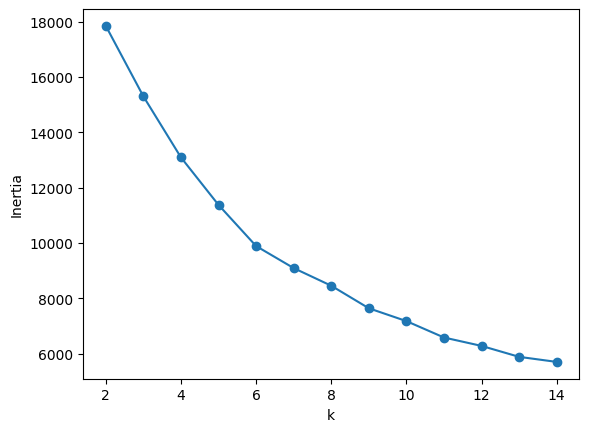

In [88]:
import matplotlib.pyplot as plt

plt.plot(K, inertia, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_39272/2973429782.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", k)   # tab10, Set2, Accent, Dark2 also good


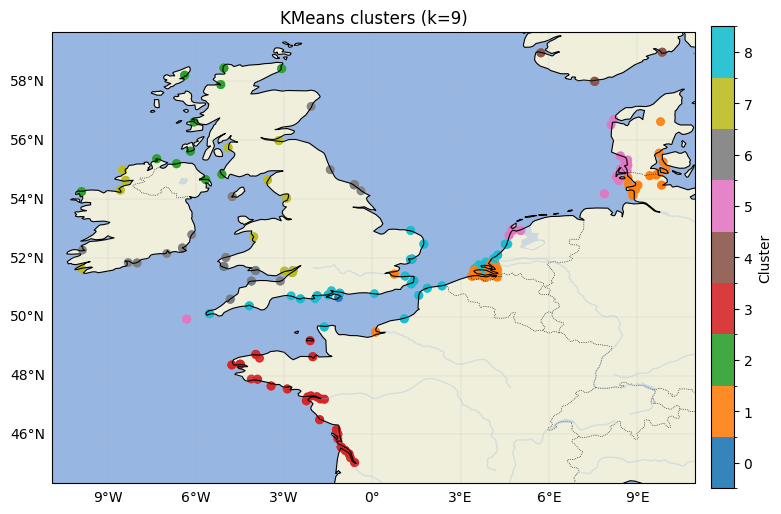

In [89]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
k = 9
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
merged["cluster"] = kmeans.fit_predict(X_scaled)

plot_df = merged.dropna(subset=["latitude", "longitude", "cluster"]).copy()

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=proj)

# Set extent based on your data (with a small padding)
min_lon, max_lon = plot_df["longitude"].min(), plot_df["longitude"].max()
min_lat, max_lat = plot_df["latitude"].min(), plot_df["latitude"].max()
pad_lon = (max_lon - min_lon) * 0.05 if max_lon > min_lon else 0.5
pad_lat = (max_lat - min_lat) * 0.05 if max_lat > min_lat else 0.5
ax.set_extent([min_lon - pad_lon, max_lon + pad_lon, min_lat - pad_lat, max_lat + pad_lat], crs=proj)

# Basemap features
ax.add_feature(cfeature.LAND, linewidth=0)
ax.add_feature(cfeature.OCEAN, linewidth=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
ax.add_feature(cfeature.LAKES, alpha=0.4)
ax.add_feature(cfeature.RIVERS, alpha=0.3)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

## ---- discrete colormap ----
cmap = plt.cm.get_cmap("tab10", k)   # tab10, Set2, Accent, Dark2 also good
bounds = np.arange(-0.5, k, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

sc = ax.scatter(
    plot_df["longitude"],
    plot_df["latitude"],
    c=plot_df["cluster"],
    cmap=cmap,
    norm=norm,
    s=30,
    alpha=0.9,
    transform=proj
)

cbar = plt.colorbar(
    sc,
    ax=ax,
    shrink=0.75,
    pad=0.02,
    boundaries=bounds,
    ticks=range(k)
)

cbar.set_label("Cluster")
cbar.set_ticklabels([f"{i}" for i in range(k)])

ax.set_title(f"KMeans clusters (k={k})")
plt.show()

In [90]:
# Ensure both cluster labels are in merged
merged = merged.copy()

merged["gev_cluster"] = model_df["cluster"].values   # existing GEV clusters
merged["met_cluster"] = merged["cluster"].values     # new kmeans clusters (rename for clarity)


In [91]:
ct_counts = pd.crosstab(merged["gev_cluster"], merged["met_cluster"])
ct_props  = ct_counts.div(ct_counts.sum(axis=1), axis=0)

print("Counts: GEV cluster × met cluster")
display(ct_counts)

print("Row proportions: within each GEV cluster, fraction in each met cluster")
display(ct_props)


Counts: GEV cluster × met cluster


met_cluster,0,1,2,3,4,5,6,7,8
gev_cluster,,,,,,,,,
0,1,30,4,9,0,20,5,13,40
1,6,17,17,40,6,3,21,9,17
2,3,12,0,0,1,4,0,1,0


Row proportions: within each GEV cluster, fraction in each met cluster


met_cluster,0,1,2,3,4,5,6,7,8
gev_cluster,,,,,,,,,
0,0.008197,0.245902,0.032787,0.073770,0.000000,0.163934,0.040984,0.106557,0.327869
1,0.044118,0.125000,0.125000,0.294118,0.044118,0.022059,0.154412,0.066176,0.125000
2,0.142857,0.571429,0.000000,0.000000,0.047619,0.190476,0.000000,0.047619,0.000000


In [92]:
from sklearn.preprocessing import StandardScaler

# X should be the feature matrix used for kmeans (no NaN columns, numeric)
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

Xs_df = pd.DataFrame(Xs, index=X.index, columns=X.columns)
Xs_df["gev_cluster"] = merged.loc[X.index, "gev_cluster"].values
Xs_df["met_cluster"] = merged.loc[X.index, "met_cluster"].values

gev_centroids_std = Xs_df.groupby("gev_cluster")[X.columns].mean()
print("GEV centroids in standardized meteorological space:")
display(gev_centroids_std)

gev_centroids_phys = pd.DataFrame(
    scaler.inverse_transform(gev_centroids_std),
    index=gev_centroids_std.index,
    columns=X.columns
)

print("GEV centroids in physical units:")
display(gev_centroids_phys)


GEV centroids in standardized meteorological space:


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q95,u10__annmax_mean,u10__annmax_std,u10__annmax_min,u10__annmax_max,...,tide__median,tide__q95,tide__annmax_mean,tide__annmax_std,tide__annmax_min,tide__annmax_max,tide__annmean_mean,tide__annmean_std,tide__annmean_min,tide__annmean_max
gev_cluster,,,,,,,,,,,,,,,,,,,,,
0,0.088038,-0.112639,0.317473,-0.241859,-0.008614,-0.054792,-0.084435,-0.005210,-0.038649,-0.241859,...,-0.163475,-0.039685,-0.028772,0.051283,-0.035748,-0.023558,-0.141427,0.049587,-0.147701,-0.132963
1,-0.090027,0.117593,-0.319369,0.231926,-0.040325,0.082743,0.126483,-0.127557,0.098991,0.231926,...,0.051374,-0.018372,-0.010407,-0.030343,-0.006980,-0.012820,0.038227,-0.042846,0.043882,0.031795
2,0.071573,-0.107175,0.223928,-0.096912,0.311195,-0.217543,-0.328598,0.856347,-0.416557,-0.096912,...,0.617009,0.349534,0.234552,-0.101425,0.252884,0.219883,0.574056,-0.010600,0.573887,0.566538


GEV centroids in physical units:


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q95,u10__annmax_mean,u10__annmax_std,u10__annmax_min,u10__annmax_max,...,tide__median,tide__q95,tide__annmax_mean,tide__annmax_std,tide__annmax_min,tide__annmax_max,tide__annmean_mean,tide__annmean_std,tide__annmean_min,tide__annmean_max
gev_cluster,,,,,,,,,,,,,,,,,,,,,
0,1.463204,4.679777,-14.611848,21.631088,1.584177,9.026230,16.574150,1.778157,13.342505,21.631088,...,-0.034985,1.929121,2.573574,0.148980,2.259324,2.860274,0.007145,0.117155,-0.197777,0.207369
1,1.407061,4.844429,-16.235027,22.924685,1.569321,9.203499,17.011209,1.747711,13.583266,22.924685,...,0.316549,1.970070,2.613593,0.139261,2.320710,2.884233,0.299793,0.105771,0.115505,0.479816
2,1.458013,4.683684,-14.850274,22.026844,1.733997,8.816459,16.068199,1.992556,12.681465,22.026844,...,1.242036,2.676933,3.147366,0.130797,2.875208,3.403418,1.172637,0.109742,0.982188,1.364073


In [93]:
gev_centroid_spread = gev_centroids_std.max(axis=0) - gev_centroids_std.min(axis=0)
gev_centroid_spread = gev_centroid_spread.sort_values(ascending=False)

print("Variables defining separation BETWEEN GEV centroids (standardized):")
print(gev_centroid_spread.head(20))


Variables defining separation BETWEEN GEV centroids (standardized):
sp__annmax_std      1.327764
msl__min            1.325497
msl__annmax_std     1.301948
v10__max            1.208553
v10__annmax_max     1.208553
v10__annmax_min     1.103982
sp__min             1.102065
tp__annmax_min      1.068593
msl__max            0.988695
msl__annmax_max     0.988695
u10__annmax_std     0.983904
v10__annmax_mean    0.980855
v10__annmax_std     0.966864
v10__q95            0.951091
sp__annmean_std     0.928300
v10__std            0.923518
msl__annmean_std    0.920400
v10__min            0.880918
msl__q95            0.868570
tide__median        0.780485
dtype: float64


In [94]:
gev_met_centroids_std = (
    Xs_df.groupby(["gev_cluster", "met_cluster"])[X.columns]
    .mean()
)
gev_met_centroids_phys = pd.DataFrame(
    scaler.inverse_transform(gev_met_centroids_std),
    index=gev_met_centroids_std.index,
    columns=X.columns
)

print("Centroids (physical units) by (GEV cluster, met cluster):")
display(gev_met_centroids_phys.head(20))


Centroids (physical units) by (GEV cluster, met cluster):


u10__mean  u10__std   u10__min   u10__max  \
gev_cluster met_cluster                                              
0           0             1.499992  4.538052 -15.504578  20.807205   
            1             1.276963  3.902257 -11.804897  19.238667   
            2             1.465931  5.285440 -18.914913  24.115204   
            3             1.107717  4.837363 -15.875461  24.346537   
            5             1.763051  5.642565 -17.557236  24.961707   
            6             1.721879  4.980566 -16.590491  22.475296   
            7             1.346740  4.032638 -12.956422  20.061124   
            8             1.537271  4.861764 -14.798113  21.326016   
1           0             1.551474  4.998350 -16.534353  22.467161   
            1             1.189576  4.112419 -13.751620  19.670706   
            2             1.564063  5.487484 -19.353033  25.415721   
            3             1.234870  5.007010 -16.076188  24.893026   
            4             0.508831  3.926100 -14.520676  17.623561   
            5             1.949384  6.020547 -18.411677  27.636551   
            6             1.806936  4.938374 -17.828678  22.725609   
            7             1.341601  3.821308 -12.864239  20.451036   
            8             1.583742  5.038683 -15.905384  21.812693   
2           0             1.336392  4.085019 -13.855596  20.294525   
            1             1.454198  4.610234 -14.307850  21.855160   
            4             0.899013  4.960058 -15.480240  19.920197   

                         u10__median   u10__q95  u10__annmax_mean  \
gev_cluster met_cluster                                             
0           0               1.462799   9.027266         16.737770   
            1               1.249363   7.786096         14.816121   
            2               1.444231  10.121085         18.631320   
            3               1.048442   9.275502         18.170690   
            5               2.198912  10.448806         18.699384   
            6               1.890488   9.688602         17.366627   
            7               1.395282   8.011421         14.836757   
            8               1.688591   9.326460         16.726618   
1           0               1.847964   9.427311         16.831768   
            1               1.418841   7.694181         14.028423   
            2               1.660988  10.472124         19.180217   
            3               1.219691   9.631939         18.400149   
            4               0.698682   6.533552         13.063859   
            5               2.218765  11.477681         20.309379   
            6               2.119873   9.489173         17.173738   
            7               1.252859   7.710445         15.160648   
            8               2.032570   9.335665         16.210317   
2           0               1.505666   7.968149         14.736916   
            1               1.679520   8.751012         15.944461   
            4               1.436745   8.157520         14.823565   

                         u10__annmax_std  u10__annmax_min  u10__annmax_max  \
gev_cluster met_cluster                                                      
0           0                   1.481219        13.261276        20.807205   
            1                   1.686495        12.061008        19.238667   
            2                   1.849206        14.812481        24.115204   
            3                   1.860245        14.586237        24.346537   
            5                   2.232189        14.788227        24.961707   
            6                   1.672610        14.192128        22.475296   
            7                   1.600783        11.586794        20.061124   
            8                   1.672577        13.620363        21.326016   
1           0                   1.592249        13.601748        22.467161   
            1                   1.626732        11.363948        19.670706   
            2                

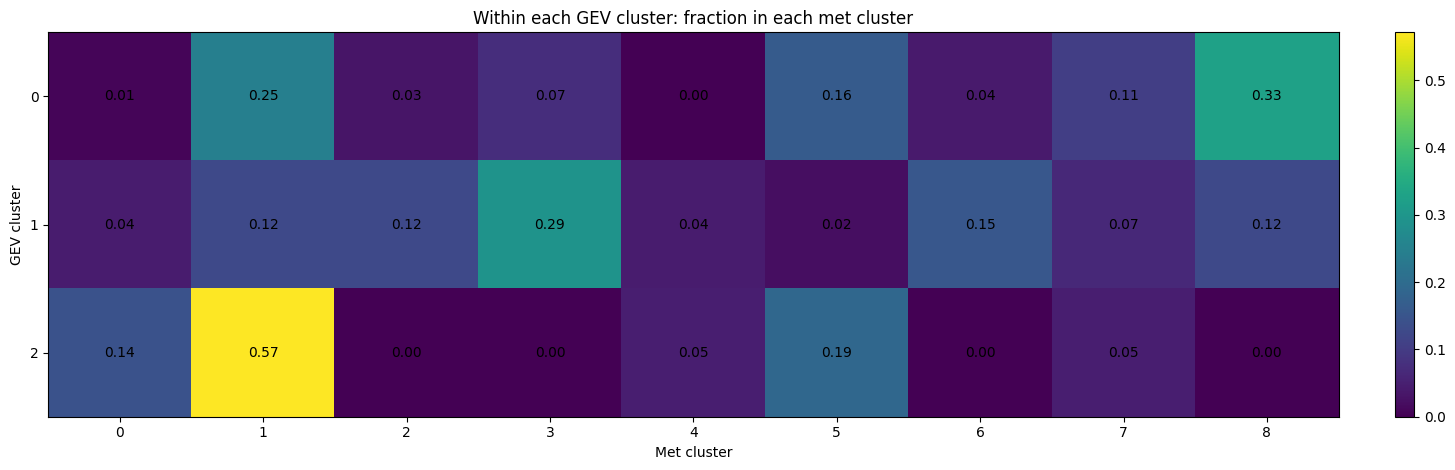

In [95]:
import numpy as np
import matplotlib.pyplot as plt

M = ct_props.values
fig, ax = plt.subplots(figsize=(1.2*ct_props.shape[1] + 4, 0.6*ct_props.shape[0] + 3))

im = ax.imshow(M, aspect="auto")
ax.set_xticks(np.arange(ct_props.shape[1]))
ax.set_yticks(np.arange(ct_props.shape[0]))
ax.set_xticklabels(ct_props.columns)
ax.set_yticklabels(ct_props.index)
ax.set_xlabel("Met cluster")
ax.set_ylabel("GEV cluster")
ax.set_title("Within each GEV cluster: fraction in each met cluster")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# annotate
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()


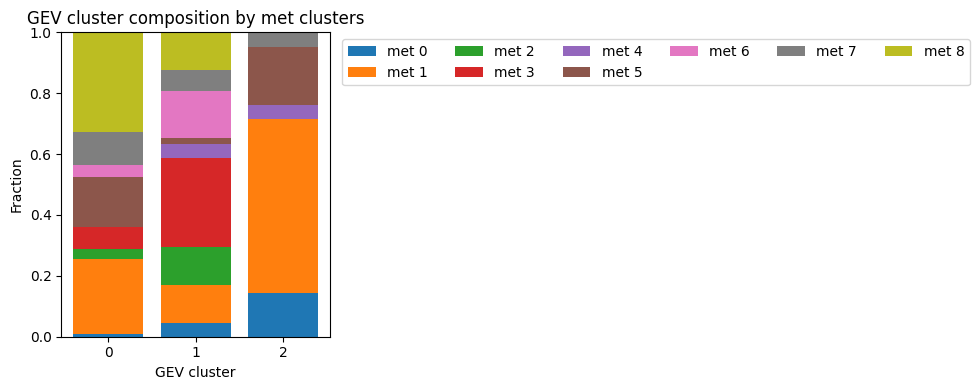

In [96]:
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(ct_props.shape[0])
bottom = np.zeros(ct_props.shape[0])

for mc in ct_props.columns:
    vals = ct_props[mc].values
    ax.bar(x, vals, bottom=bottom, label=f"met {mc}")
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(ct_props.index)
ax.set_xlabel("GEV cluster")
ax.set_ylabel("Fraction")
ax.set_title("GEV cluster composition by met clusters")
ax.legend(ncol=min(6, len(ct_props.columns)), bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


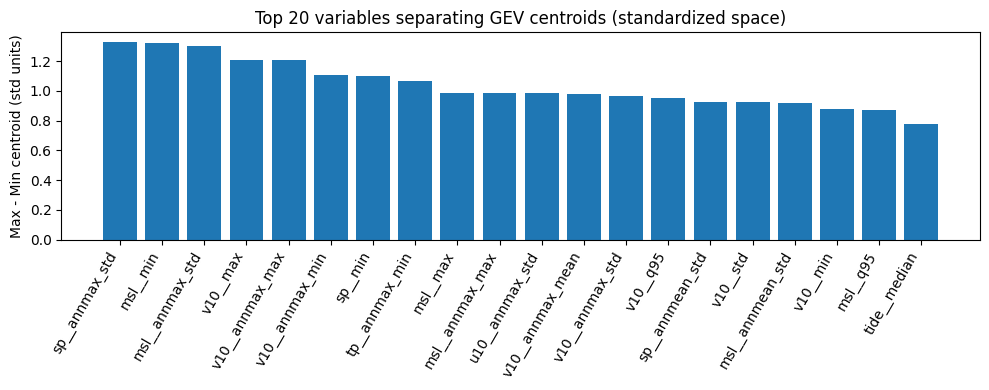

In [97]:
topn = 20
top = gev_centroid_spread.head(topn)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(len(top)), top.values)
ax.set_xticks(np.arange(len(top)))
ax.set_xticklabels(top.index, rotation=60, ha="right")
ax.set_ylabel("Max - Min centroid (std units)")
ax.set_title(f"Top {topn} variables separating GEV centroids (standardized space)")
plt.tight_layout()
plt.show()


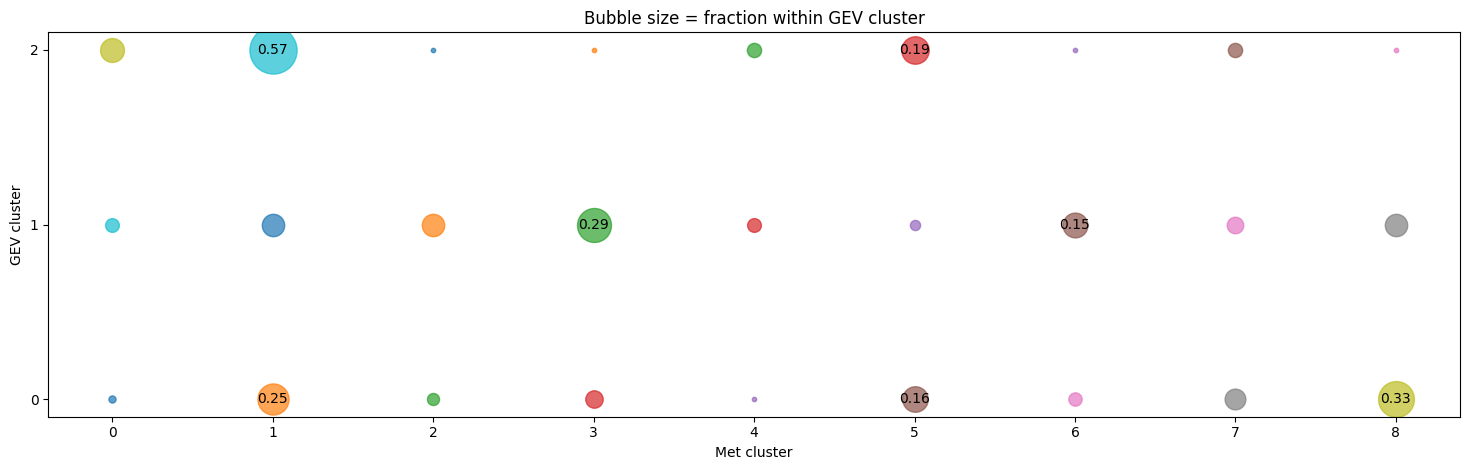

In [98]:
# Use proportions; size encodes ct_props, text shows value
rows = ct_props.index.tolist()
cols = ct_props.columns.tolist()

fig, ax = plt.subplots(figsize=(1.2*len(cols)+4, 0.6*len(rows)+3))

for i, r in enumerate(rows):
    for j, c in enumerate(cols):
        v = ct_props.loc[r, c]
        ax.scatter(j, i, s=2000*v + 10, alpha=0.7)
        if v >= 0.15:  # label only meaningful bubbles
            ax.text(j, i, f"{v:.2f}", ha="center", va="center")

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(rows)))
ax.set_xticklabels(cols)
ax.set_yticklabels(rows)
ax.set_xlabel("Met cluster")
ax.set_ylabel("GEV cluster")
ax.set_title("Bubble size = fraction within GEV cluster")
plt.tight_layout()
plt.show()



In [99]:
from sklearn.metrics import pairwise_distances
# standardized feature table with both labels
Xs_df   # columns = X.columns + ["gev_cluster", "met_cluster"]

# met cluster centroids (from kmeans)
met_centroids_std = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

# GEV centroids in standardized space
gev_centroids_std = Xs_df.groupby("gev_cluster")[X.columns].mean()

D = pairwise_distances(gev_centroids_std, met_centroids_std, metric="euclidean")

D_df = pd.DataFrame(
    D,
    index=gev_centroids_std.index,
    columns=[f"met_{i}" for i in met_centroids_std.index]
)

print("Distance: GEV centroid → met centroid (std space)")
display(D_df)


Distance: GEV centroid → met centroid (std space)


,met_0,met_1,met_2,met_3,met_4,met_5,met_6,met_7,met_8
gev_cluster,,,,,,,,,
0,15.465388,4.700412,12.711268,6.899235,15.299761,6.587845,6.015065,10.779483,2.289814
1,14.893717,7.090425,10.655300,6.961019,14.145393,6.864954,4.859990,9.548331,4.035913
2,14.365423,4.687799,13.374372,9.481443,14.143597,7.085467,8.073164,11.052972,5.908288


In [100]:
best_match = D_df.idxmin(axis=1)
best_dist  = D_df.min(axis=1)

summary = pd.DataFrame({
    "best_met_cluster": best_match,
    "distance": best_dist
})

display(summary)


,best_met_cluster,distance
gev_cluster,,
0,met_8,2.289814
1,met_8,4.035913
2,met_1,4.687799


In [101]:
feature_importance = {}

for g in gev_centroids_std.index:
    m = int(best_match.loc[g].split("_")[1])
    
    diff = gev_centroids_std.loc[g] - met_centroids_std.loc[m]
    contrib = diff**2
    contrib = contrib.sort_values(ascending=False)
    
    feature_importance[g] = contrib

# Example: top drivers for GEV cluster 0
display(feature_importance[0].head(15))


u10__annmax_std      0.461166
msl__annmax_min      0.235684
v10__annmax_max      0.220643
v10__max             0.220643
msl__annmax_std      0.214722
sp__annmax_std       0.212529
u10__median          0.195254
v10__annmax_mean     0.174606
v10__annmax_min      0.131500
tp__annmax_std       0.124683
v10__annmax_std      0.123727
msl__median          0.123484
msl__annmean_max     0.118652
msl__mean            0.108659
msl__annmean_mean    0.108645
dtype: float64

In [102]:
topN = 10
tables = []

for g in gev_centroids_std.index:
    m = int(best_match.loc[g].split("_")[1])
    
    diff = gev_centroids_std.loc[g] - met_centroids_std.loc[m]
    out = pd.DataFrame({
        "feature": X.columns,
        "gev_centroid": gev_centroids_std.loc[g].values,
        "met_centroid": met_centroids_std.loc[m].values,
        "abs_diff": diff.abs().values,
        "sq_contribution": (diff**2).values
    }).sort_values("sq_contribution", ascending=False)
    
    out["gev_cluster"] = g
    out["best_met_cluster"] = m
    
    tables.append(out.head(topN))

important_features = pd.concat(tables)
display(important_features)


,feature,gev_centroid,met_centroid,abs_diff,sq_contribution,gev_cluster,best_met_cluster
7,u10__annmax_std,-0.005210,-0.684302,0.679092,0.461166,0,8
36,msl__annmax_min,0.062218,0.547691,0.485473,0.235684,0,8
23,v10__annmax_max,-0.237547,0.232180,0.469727,0.220643,0,8
17,v10__max,-0.237547,0.232180,0.469727,0.220643,0,8
35,msl__annmax_std,-0.083306,-0.546687,0.463381,0.214722,0,8
49,sp__annmax_std,-0.074814,-0.535822,0.461009,0.212529,0,8
4,u10__median,-0.008614,0.433261,0.441875,0.195254,0,8
20,v10__annmax_mean,-0.143538,0.274320,0.417858,0.174606,0,8
22,v10__annmax_min,-0.142678,0.219951,0.362629,0.131500,0,8
63,tp__annmax_std,0.287973,0.641078,0.353105,0.124683,0,8


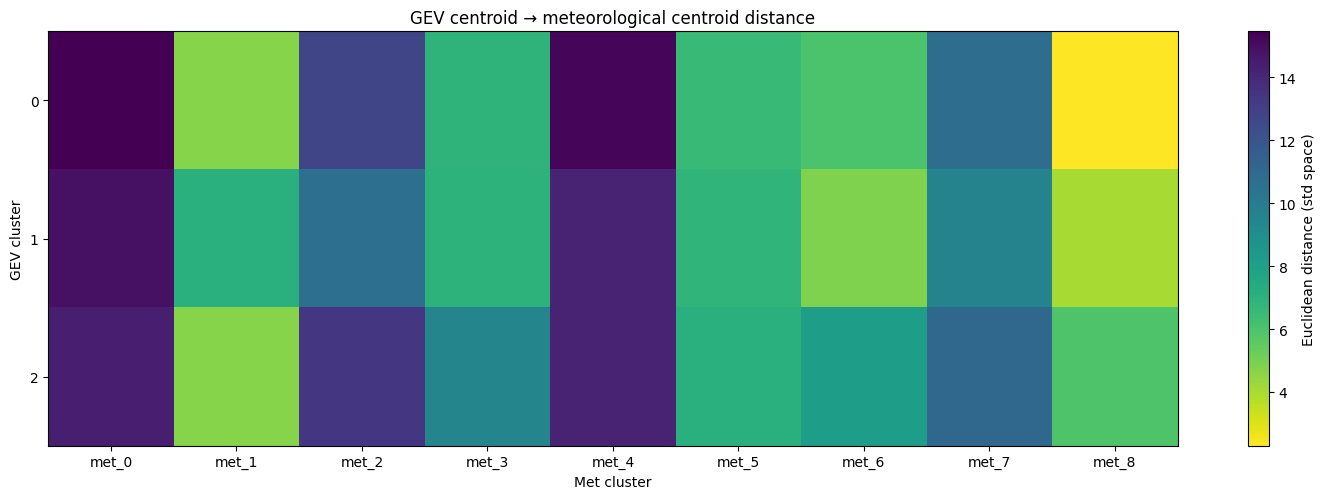

In [107]:
plt.figure(figsize=(1.2*D_df.shape[1]+4, 0.7*D_df.shape[0]+3))
plt.imshow(D_df.values, aspect="auto", cmap="viridis_r")
plt.xticks(range(D_df.shape[1]), D_df.columns)
plt.yticks(range(D_df.shape[0]), D_df.index)
plt.colorbar(label="Euclidean distance (std space)")
plt.xlabel("Met cluster")
plt.ylabel("GEV cluster")
plt.title("GEV centroid → meteorological centroid distance")
plt.tight_layout()
plt.show()


In [108]:
g = 1  # example GEV cluster
m = int(best_match.loc[g].split("_")[1])

diff = (gev_centroids_std.loc[g] - met_centroids_std.loc[m]).abs()
similarity = -diff   # smaller diff = more similar

similarity = similarity.sort_values(ascending=False)
display(similarity.head(15))


tp__min             -0.000000
v10__std            -0.020337
v10__q95            -0.021472
v10__annmax_mean    -0.031584
v10__annmean_max    -0.033264
u10__annmax_min     -0.034547
v10__annmax_min     -0.038586
v10__min            -0.040772
msl__q95            -0.058016
v10__mean           -0.063380
v10__annmean_mean   -0.065325
v10__annmax_std     -0.066280
v10__annmean_min    -0.076255
tp__annmax_mean     -0.080209
u10__annmean_std    -0.082524
dtype: float64

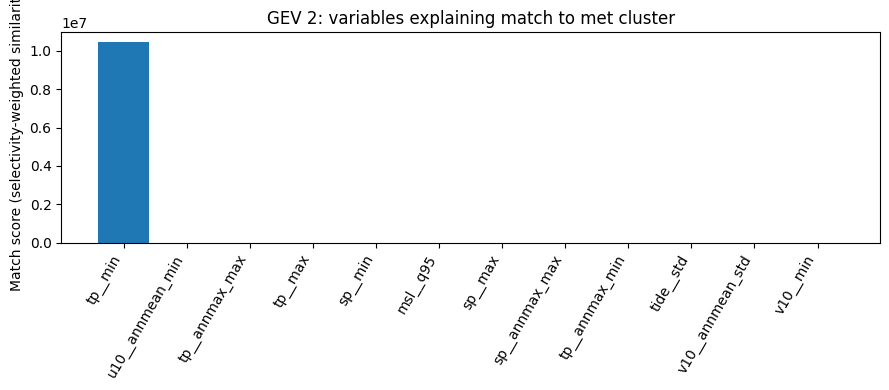

In [114]:
g = 2
eps = 1e-6
match_scores = {}

for g in gev_centroids_std.index:
    dists = D_df.loc[g]
    m = dists.idxmin()
    
    d_best = dists[m]
    d_others = dists.drop(m).mean()
    
    diff_best = (gev_centroids_std.loc[g] - met_centroids_std.loc[int(m.split("_")[1])]).abs()
    
    score = d_others / (diff_best + eps)
    score = score.sort_values(ascending=False)
    
    match_scores[g] = score


top = match_scores[g].head(12)

plt.figure(figsize=(9,4))
plt.bar(range(len(top)), top.values)
plt.xticks(range(len(top)), top.index, rotation=60, ha="right")
plt.ylabel("Match score (selectivity-weighted similarity)")
plt.title(f"GEV {g}: variables explaining match to met cluster")
plt.tight_layout()
plt.show()


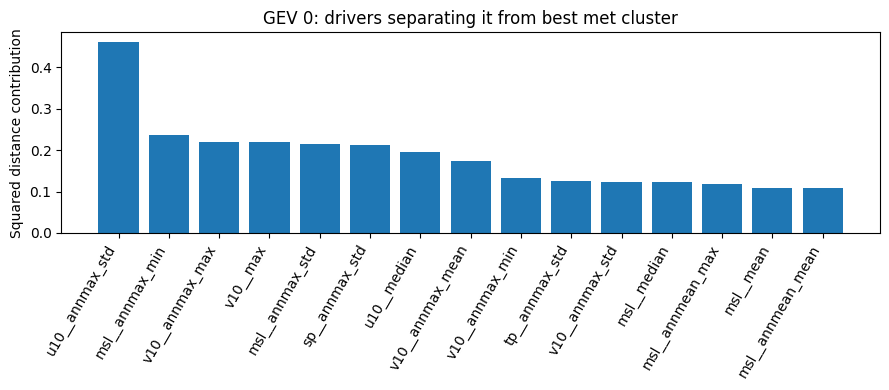

In [104]:
g = gev_centroids_std.index[0]  # choose cluster
top = feature_importance[g].head(15)

plt.figure(figsize=(9,4))
plt.bar(range(len(top)), top.values)
plt.xticks(range(len(top)), top.index, rotation=60, ha="right")
plt.ylabel("Squared distance contribution")
plt.title(f"GEV {g}: drivers separating it from best met cluster")
plt.tight_layout()
plt.show()


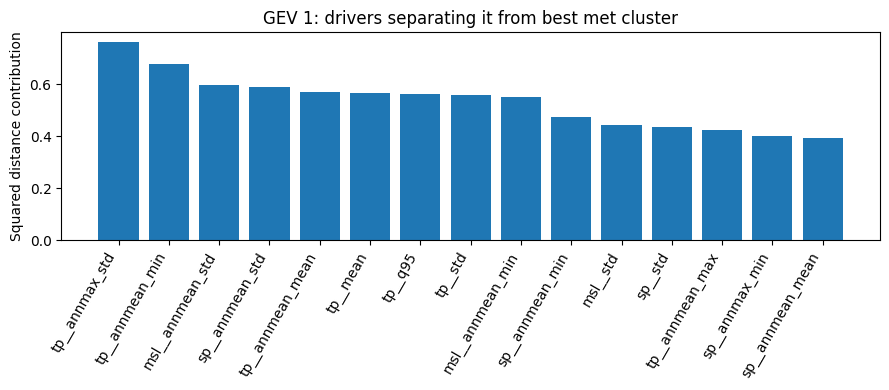

In [105]:
g = gev_centroids_std.index[1]  # choose cluster
top = feature_importance[g].head(15)

plt.figure(figsize=(9,4))
plt.bar(range(len(top)), top.values)
plt.xticks(range(len(top)), top.index, rotation=60, ha="right")
plt.ylabel("Squared distance contribution")
plt.title(f"GEV {g}: drivers separating it from best met cluster")
plt.tight_layout()
plt.show()

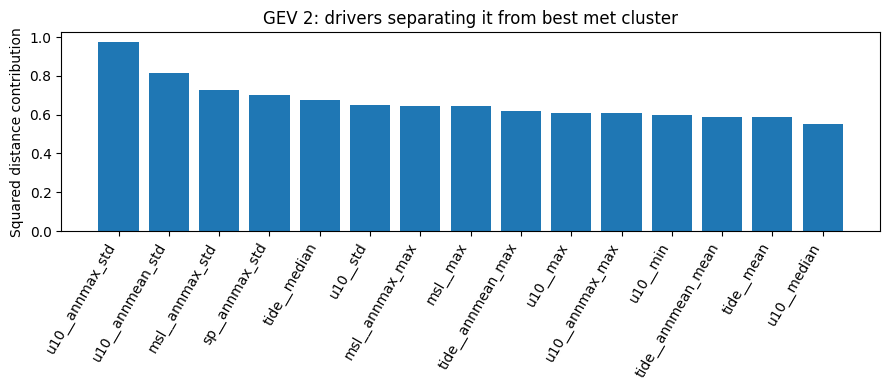

In [106]:
g = gev_centroids_std.index[2]  # choose cluster
top = feature_importance[g].head(15)

plt.figure(figsize=(9,4))
plt.bar(range(len(top)), top.values)
plt.xticks(range(len(top)), top.index, rotation=60, ha="right")
plt.ylabel("Squared distance contribution")
plt.title(f"GEV {g}: drivers separating it from best met cluster")
plt.tight_layout()